# Election forecasting: data setup and EDA

State-level polling data for the 2004, 2008, and 2012 US presidential
elections, 145 state-year rows, predicting which party won each state.
Two national pollsters (Rasmussen and SurveyUSA) each publish a poll
margin, `PropR` is the share of all polls that favored the Republican,
and `DiffCount` is how many more Republican-favoring polls there were
than Democrat-favoring ones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('PollingData.csv')
df.shape

(145, 7)

In [2]:
df.Year.value_counts().sort_index()

Year
2004    50
2008    50
2012    45
Name: count, dtype: int64

In [3]:
df.isnull().sum()

State          0
Year           0
Rasmussen     46
SurveyUSA     71
DiffCount      0
PropR          0
Republican     0
dtype: int64

Rasmussen is missing for 46 of 145 rows and SurveyUSA for 71, both pollsters simply didn't cover every state in every election. `PropR` and `DiffCount`, aggregated from every poll available rather than one named pollster, have no gaps at all.

In [4]:
df.Republican.value_counts()

Republican
1    74
0    71
Name: count, dtype: int64

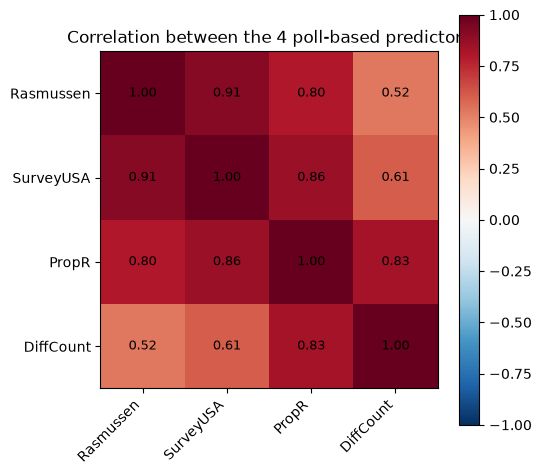

In [5]:
corr = df[['Rasmussen', 'SurveyUSA', 'PropR', 'DiffCount']].corr()
fig, ax = plt.subplots(figsize = (5.5, 5))
im = ax.imshow(corr, cmap = 'RdBu_r', vmin = -1, vmax = 1)
ax.set_xticks(range(4)); ax.set_xticklabels(corr.columns, rotation = 45, ha = 'right')
ax.set_yticks(range(4)); ax.set_yticklabels(corr.columns)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha = 'center', va = 'center', fontsize = 9)
plt.colorbar(im)
plt.title('Correlation between the 4 poll-based predictors')
plt.tight_layout()
plt.savefig('outputs/poll_correlation.png', dpi = 120)
plt.show()

All four move together closely (0.51 to 0.91), unsurprising since they're all measuring the same underlying thing, which state leans which way, from slightly different angles. That's a real multicollinearity concern for a model using more than one of them at once, checked properly with a variance inflation factor in the next notebook.

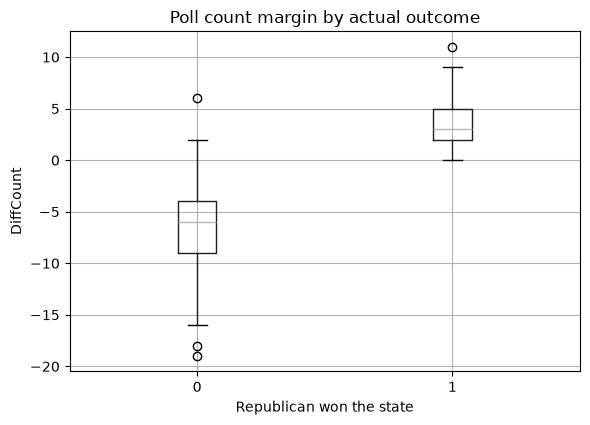

In [6]:
fig, ax = plt.subplots(figsize = (6, 4.5))
df.boxplot(column = 'DiffCount', by = 'Republican', ax = ax)
ax.set_xlabel('Republican won the state'); ax.set_ylabel('DiffCount')
plt.suptitle('')
ax.set_title('Poll count margin by actual outcome')
plt.tight_layout()
plt.savefig('outputs/diffcount_by_outcome.png', dpi = 120)
plt.show()

In [7]:
import os, json
os.makedirs('outputs', exist_ok = True)
summary = {
    'n_rows': int(df.shape[0]),
    'years': sorted(df.Year.unique().tolist()),
    'n_missing_rasmussen': int(df.Rasmussen.isnull().sum()),
    'n_missing_surveyusa': int(df.SurveyUSA.isnull().sum()),
    'republican_share': float(df.Republican.mean()),
}
with open('outputs/data_summary.json', 'w') as f:
    json.dump(summary, f, indent = 2)
summary

{'n_rows': 145,
 'years': [2004, 2008, 2012],
 'n_missing_rasmussen': 46,
 'n_missing_surveyusa': 71,
 'republican_share': 0.5103448275862069}